## Поиск лучшей перестановки

In [5]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


NUM_OF_FEATURES = 50
RANDOM_STATE = 42


features_df = pd.read_csv('DATA/features/REAL_features_ws256_overlap75.csv')
selected_features = ['gy_TD_dif_dif_Min', 'gz_TD_dif_Min', 'ax_TD_Min', 'gz_TD_dif_dif_Min', 'ax_TD_dif_dif_Min', 'ay_TD_Min', 'ax_TD_dif_Min', 'gy_TD_Min', 'az_TD_Min', 'gy_TD_dif_Min', 'gx_TD_dif_Min', 'ay_TD_dif_Min', 'az_TD_dif_dif_Max', 'ay_TD_dif_dif_Max', 'ax_TD_dif_dif_Max', 'gz_TD_dif_dif_Max', 'gz_TD_dif_Max', 'gz_TD_Max', 'ax_TD_Max', 'ay_TD_Max', 'gy_TD_dif_dif_Max', 'az_TD_Max', 'ax_TD_dif_Max', 'gy_TD_dif_Max', 'gx_TD_dif_Max', 'gy_TD_Max', 'az_TD_dif_Max', 'gx_TD_Min', 'gy_TD_dif_dif_CumsumFinal', 'gz_TD_L1', 'az_TD_L1', 'gz_TD_dif_dif_L1', 'gx_TD_dif_L1', 'gy_TD_dif_dif_L1', 'ax_TD_dif_dif_L1', 'ax_TD_L1', 'ay_TD_dif_L1', 'ay_TD_L1', 'gz_TD_dif_L1', 'az_TD_dif_dif_L1', 'ay_TD_dif_dif_L1', 'az_TD_dif_Mean', 'gy_TD_Mean', 'gx_TD_Ptp', 'gx_TD_dif_Ptp', 'az_TD_dif_dif_Ptp', 'gz_TD_dif_Ptp', 'ay_TD_dif_Ptp', 'ax_TD_dif_dif_Ptp', 'az_TD_dif_Ptp']

X = features_df.to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

n_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

candidates = [
    [0, 1, 4, 2, 3],
    [0, 1, 4, 2, 3],
    [0, 1, 4, 2, 3],
    [0, 1, 2, 3, 4],
    [0, 1, 2, 4, 3],
    [0, 1, 2, 4, 3]
]


def evaluate_permutation(perm):
    
    mapping = {old: new for new, old in enumerate(perm)}
    y_train_m = np.array([mapping[v] for v in y_train])
    y_test_m = np.array([mapping[v] for v in y_test])

    models = []
    for k in range(1, n_classes):
        y_binary = (y_train_m >= k).astype(int)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        clf.fit(X_train_scaled, y_binary)
        models.append(clf)

    latent_test = np.mean([m.decision_function(X_test_scaled) for m in models], axis=0)
    spearman, _ = spearmanr(latent_test, y_test_m)
    means = [np.mean(latent_test[y_test_m == c]) for c in range(n_classes)]
    monotonic = all(means[i] < means[i+1] for i in range(n_classes-1))

    return spearman, monotonic, models, mapping


best_spearman = -np.inf
best_models = None
best_mapping = None

for perm in candidates:
    spearman, monotonic, models, mapping = evaluate_permutation(perm)

    if monotonic and spearman > best_spearman:
        best_spearman = spearman
        best_models = models
        best_mapping = mapping

print("Spearman:", round(best_spearman, 4))

if best_models is None:
    raise ValueError("Ни одна перестановка не дала монотонный порядок.")

latent_train = np.mean([m.decision_function(X_train_scaled) for m in best_models], axis=0)

latent_min = latent_train.min()
latent_max = latent_train.max()

# with open(r"DATA/real_time/ordinal_pipeline.pkl", "wb") as f:
#     pickle.dump({
#         "models": best_models,
#         "scaler": scaler,
#         "mapping": best_mapping,
#         "features": selected_features,
#         "latent_min": latent_min,
#         "latent_max": latent_max
#     }, f)


Spearman: 0.9792


Лучшая перестановка: [0, 1, 2, 3, 4]

Статистика Latent Risk по классам:

  Новый класс 0 (исх.0): средний риск = 18.74%
  Новый класс 1 (исх.1): средний риск = 34.10%
  Новый класс 2 (исх.2): средний риск = 52.68%
  Новый класс 3 (исх.3): средний риск = 70.56%
  Новый класс 4 (исх.4): средний риск = 88.59%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максисмум
0,0,18.74,5.18,17.81,14.55,22.26,0.00,29.40
1,1,34.10,3.54,33.17,31.79,34.95,26.73,44.97
2,2,52.68,2.13,52.59,51.14,54.12,46.15,76.44
3,3,70.56,2.64,70.57,69.04,72.07,12.92,81.64
4,4,88.59,3.70,89.40,87.30,91.07,70.86,99.22


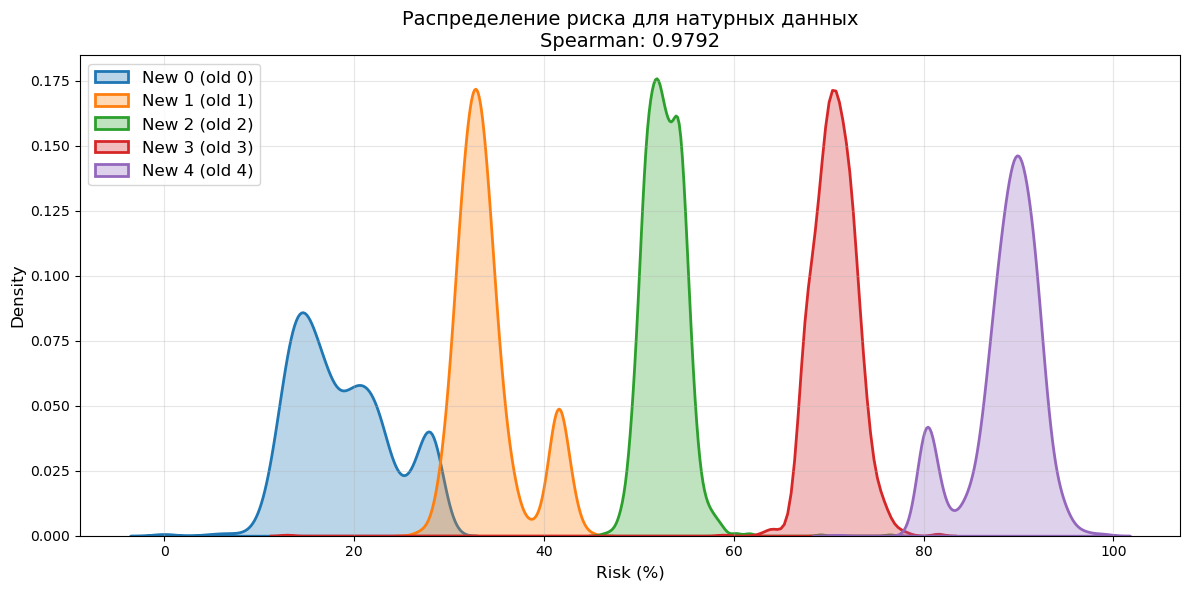

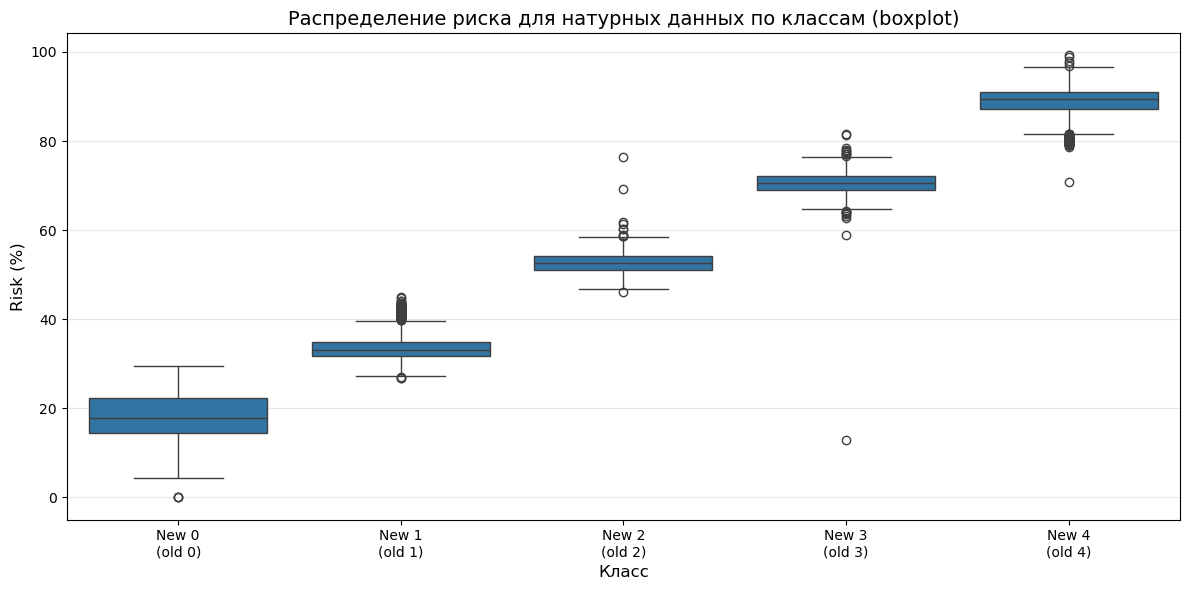

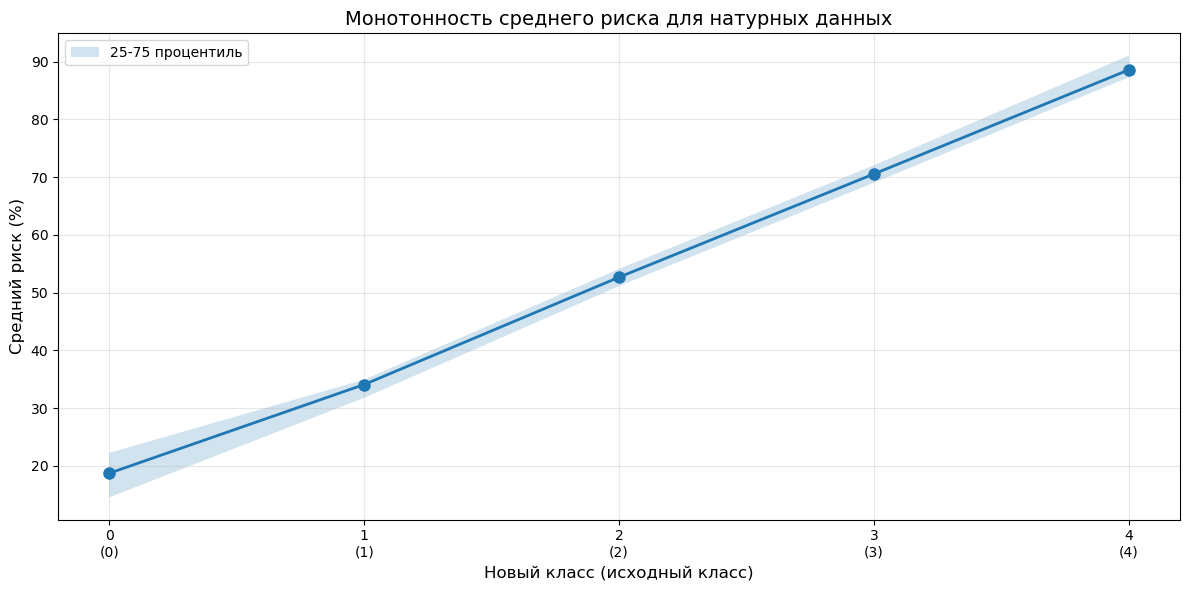

In [7]:
# Преобразуем y_test с помощью best_mapping
best_y_test_m = np.array([best_mapping[v] for v in y_test])

# Вычисляем latent для теста
best_latent = np.mean([m.decision_function(X_test_scaled) for m in best_models], axis=0)

# Приводим к процентной шкале 0-100
risk_latent = 100 * (best_latent - latent_min) / (latent_max - latent_min)
risk_latent = np.clip(risk_latent, 0, 100)

inverse_mapping = {v: k for k, v in best_mapping.items()}
best_perm_list = [inverse_mapping[i] for i in range(n_classes)]
print("Лучшая перестановка:", best_perm_list)

risk_latent = 100 * (best_latent - latent_min) / (latent_max - latent_min)
risk_latent = np.clip(risk_latent, 0, 100)

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_latent[best_y_test_m == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максисмум': np.max(data)
    })

    print(f"  Новый класс {new_class} (исх.{old_class}): средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")

display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максисмум': '{:.2f}'
}))

plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_latent[best_y_test_m == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )

plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(f"Распределение риска для натурных данных\nSpearman: {best_spearman:.4f}", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution.png', dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_latent[best_y_test_m == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'New {new_class}\n(old {old_class})'] * sum(best_y_test_m == new_class)
    )

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

sns.boxplot(data=df_box, x='Class', y='Risk')

plt.title('Распределение риска для натурных данных по классам (boxplot)', fontsize=14)
plt.ylabel('Risk (%)', fontsize=12)
plt.xlabel('Класс', fontsize=12)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot.png', dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))

means = [np.mean(risk_latent[best_y_test_m == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8)
plt.fill_between(
    new_classes,
    [np.percentile(risk_latent[best_y_test_m == c], 25) for c in new_classes],
    [np.percentile(risk_latent[best_y_test_m == c], 75) for c in new_classes],
    alpha=0.2,
    label='25-75 процентиль'
)

plt.xticks(new_classes, old_labels)
plt.xlabel('Новый класс (исходный класс)', fontsize=12)
plt.ylabel('Средний риск (%)', fontsize=12)
plt.title('Монотонность среднего риска для натурных данных', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity.png', dpi=400, bbox_inches='tight')
plt.show()

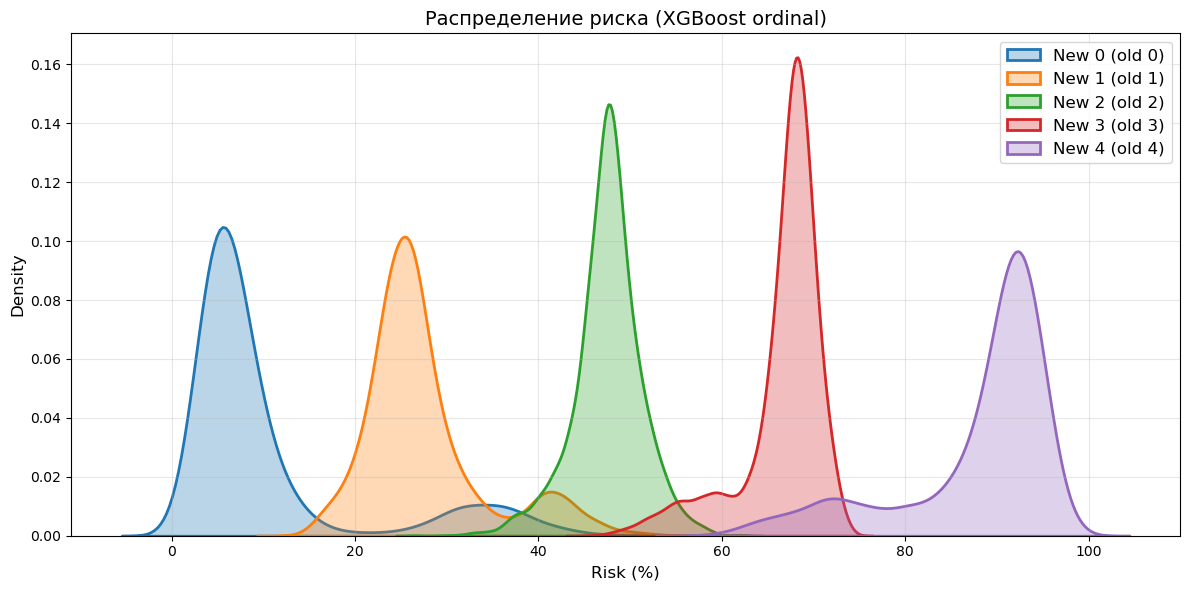

In [9]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 50
RANDOM_STATE = 42

# ==================== ДАННЫЕ ====================
features_df = pd.read_csv('DATA/features/REAL_features_ws256_overlap75.csv')

X = features_df[selected_features].to_numpy(dtype=np.float32)
y_raw = features_df["Класс"].to_numpy()

# Упорядочиваем классы (сильный риск → больший индекс)
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_raw), reverse=True))}
y = np.array([class_mapping[val] for val in y_raw])

n_classes = len(np.unique(y))

# ==================== МАСШТАБИРОВАНИЕ ====================
# (Для XGBoost не обязательно, но оставим для совместимости пайплайна)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================== ФИКСИРОВАННАЯ ПЕРЕСТАНОВКА ====================
fixed_perm = [0, 1, 2, 3, 4]
mapping = {old: new for new, old in enumerate(fixed_perm)}
y_mapped = np.array([mapping[v] for v in y])

# ==================== ОБУЧЕНИЕ CUMULATIVE MODELS ====================
models = []

for k in range(1, n_classes):

    y_binary = (y_mapped >= k).astype(int)

    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        tree_method="hist",  # быстрый CPU режим
        n_jobs=-1
    )

    clf.fit(X_scaled, y_binary)
    models.append(clf)

# ==================== LATENT (margin, не probability!) ====================
latent_all = np.mean(
    [m.predict(X_scaled, output_margin=True) for m in models],
    axis=0
)

# ==================== НОРМАЛИЗАЦИЯ В 0–100 ====================
latent_min = latent_all.min()
latent_max = latent_all.max()

risk_latent = 100 * (latent_all - latent_min) / (latent_max - latent_min)
risk_latent = np.clip(risk_latent, 0, 100)

inverse_mapping = {v: k for k, v in mapping.items()}

# ==================== ВИЗУАЛИЗАЦИЯ ====================
plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_latent[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )

plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Распределение риска (XGBoost ordinal)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()